# Getting rating curves from different streams in VCNP

Import data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import linregress

lajara_2021 = pd.read_csv("la_jara/discharge_2021.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # first column is datetime and second column is discharge in m3/s
lajara_2022 = pd.read_csv("la_jara/discharge_2022.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
lajara_2023 = pd.read_csv("la_jara/discharge_2023.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # m3/s
redondo = pd.read_csv("redondo/DataSetExport-Discharge.Discharge@VALL_MIRLKE-Maximum-ft^3 s-20260223140410.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
san_antonio = pd.read_csv("san_antonio/DataSetExport-Discharge.Discharge@VALL_RSAWES-Maximum-ft^3 s-20260302191152.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s
lower_sulphur = pd.read_csv("lower_sulphur/DataSetExport-Discharge.Discharge (Daily Mean)@VALL_LWRSUL-Maximum-ft^3 s-20260302190628.csv", parse_dates=[0], index_col=0, na_values=['NaN'])
upper_sulphur = pd.read_csv("upper_sulphur/DataSetExport-Discharge.Discharge@VALL_UPRSUL-Maximum-ft^3 s-20260302181951.csv", parse_dates=[0], index_col=0, na_values=['NaN']) # ft^3/s

In [2]:
# convert ft^3/s to m3/s for redondo, san_antonio, lower_sulphur, and upper_sulphur
redondo["redondo (m3/s)"] = redondo["Value (ft^3/s)"] * 0.0283168
san_antonio["san_antonio (m3/s)"] = san_antonio["Value (ft^3/s)"] * 0.0283168
lower_sulphur["lower_sulphur (m3/s)"] = lower_sulphur["Value (ft^3/s)"] * 0.0283168
upper_sulphur["upper_sulphur (m3/s)"] = upper_sulphur["Value (ft^3/s)"] * 0.0283168

# la jara data as base 
lajara_2021.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2022.rename(columns={'Q': 'la_jara'}, inplace=True)
lajara_2023.rename(columns={'Q': 'la_jara'}, inplace=True)

In [102]:
# keep data in each year starting from Aug 1 and ending Aug 28
lajara_2021 = lajara_2021[(lajara_2021.index >= '2021-08-01') & (lajara_2021.index < '2021-08-29')]
lajara_2022 = lajara_2022[(lajara_2022.index >= '2022-08-01') & (lajara_2022.index < '2022-08-29')]
lajara_2023 = lajara_2023[(lajara_2023.index >= '2023-08-01') & (lajara_2023.index < '2023-08-29')]

## 2021

In [103]:
# merge all onto la_jara 2021 index (inner join to only keep dates available in la_jara_2021)
merged_2021 = lajara_2021.copy()
merged_2021 = merged_2021.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']]
], how='left')

print(merged_2021.head())
print(f"Shape: {merged_2021.shape}")

                      la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2021-08-01 00:00:00  0.009732        0.003470            0.114706   
2021-08-01 00:15:00  0.009732        0.003794            0.115739   
2021-08-01 00:30:00  0.009732        0.003763            0.117097   
2021-08-01 00:45:00  0.009732        0.003467            0.120654   
2021-08-01 01:00:00  0.009732        0.003467            0.117900   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  
2021-08-01 00:00:00              0.014357              0.010209  
2021-08-01 00:15:00                   NaN              0.010539  
2021-08-01 00:30:00                   NaN              0.010638  
2021-08-01 00:45:00                   NaN              0.010510  
2021-08-01 01:00:00                   NaN              0.010311  
Shape: (2688, 5)


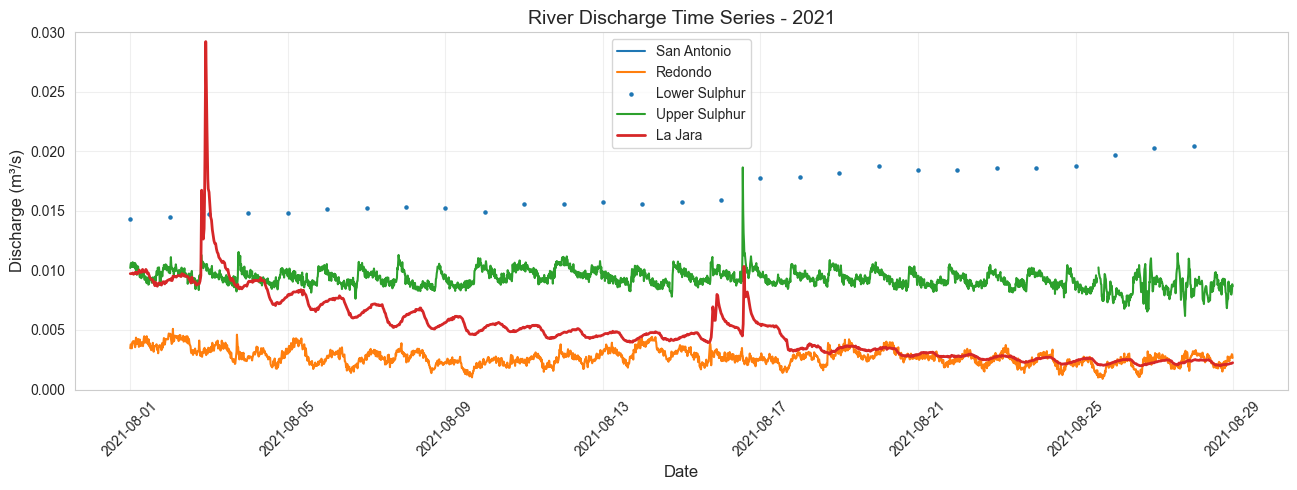

In [104]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2021.index, merged_2021['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.scatter(merged_2021.index, merged_2021['lower_sulphur (m3/s)'], label='Lower Sulphur', s=5)
ax.plot(merged_2021.index, merged_2021['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)
ax.plot(merged_2021.index, merged_2021['la_jara'], label='La Jara', linewidth=2)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2021', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(0, 0.03)
plt.show()

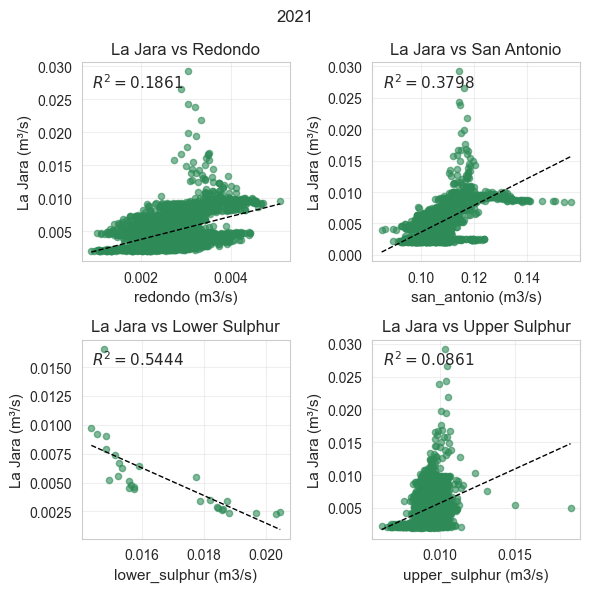

In [105]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2021', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2021[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2022

In [106]:
merged_2022 = lajara_2022.copy()
merged_2022 = merged_2022.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']]
], how='left')

print(merged_2022.head())
print(f"Shape: {merged_2022.shape}")

                      la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2022-08-01 00:00:00  0.007120        0.008724            0.250340   
2022-08-01 00:15:00  0.006257        0.008664            0.249357   
2022-08-01 00:30:00  0.006677        0.008425            0.245818   
2022-08-01 00:45:00  0.006677        0.009048            0.245451   
2022-08-01 01:00:00  0.006677        0.008545            0.241461   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  
2022-08-01 00:00:00              0.007619              0.005346  
2022-08-01 00:15:00                   NaN              0.005164  
2022-08-01 00:30:00                   NaN              0.004985  
2022-08-01 00:45:00                   NaN              0.005385  
2022-08-01 01:00:00                   NaN              0.005630  
Shape: (2689, 5)


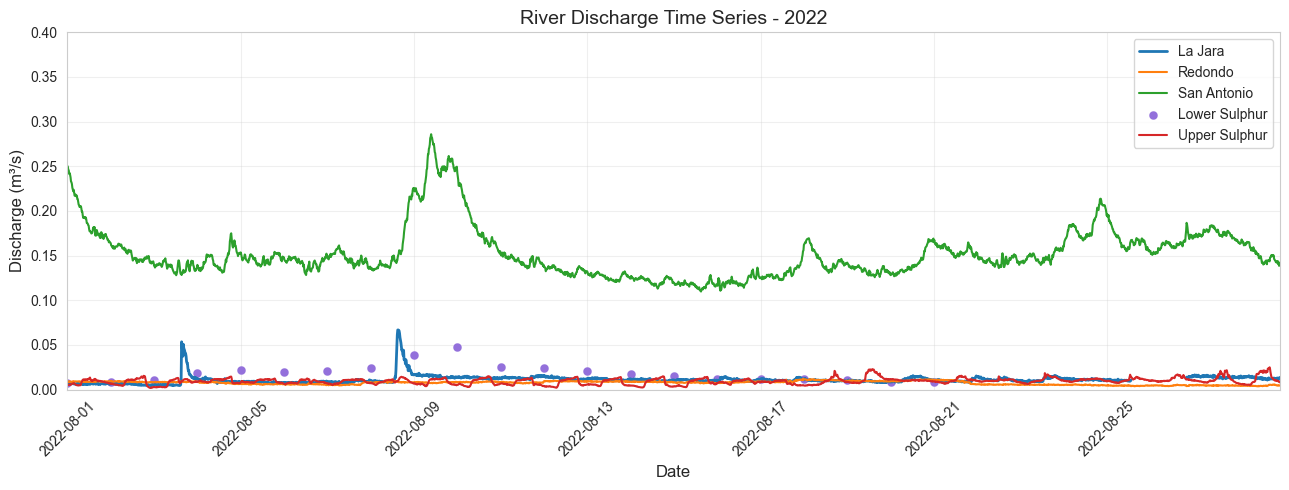

In [107]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2022.index, merged_2022['la_jara'], label='La Jara', linewidth=2)
ax.plot(merged_2022.index, merged_2022['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2022.index, merged_2022['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.scatter(merged_2022.index, merged_2022['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=0.1, color='mediumpurple')
ax.plot(merged_2022.index, merged_2022['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2022', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylim(0,0.4)

plt.xlim(pd.to_datetime('2022-08-01'), merged_2022.index.max())

plt.show()

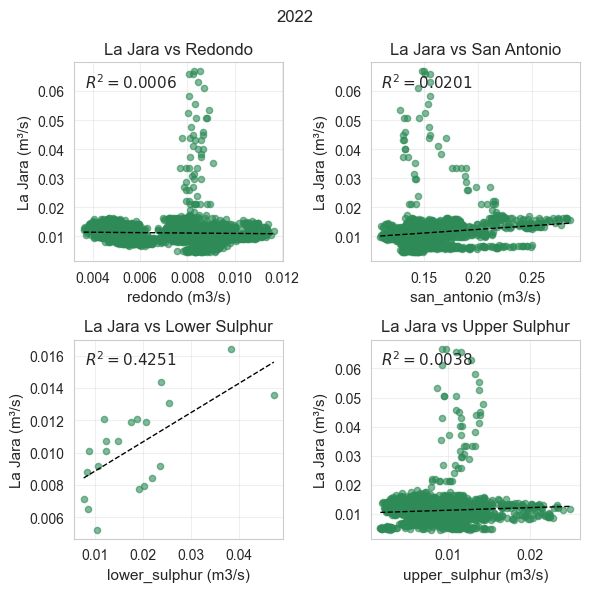

In [108]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2022', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2022[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2023

In [109]:
# merge all onto la_jara 2021 index (inner join to only keep dates available in la_jara_2021)
merged_2023 = lajara_2023.copy()
merged_2023 = merged_2023.join([
    redondo[['redondo (m3/s)']],
    san_antonio[['san_antonio (m3/s)']],
    lower_sulphur[['lower_sulphur (m3/s)']],
    upper_sulphur[['upper_sulphur (m3/s)']]
], how='left')

print(merged_2023.head())
print(f"Shape: {merged_2023.shape}")

                      la_jara  redondo (m3/s)  san_antonio (m3/s)  \
2023-08-01 00:00:00  0.005901             NaN            0.091972   
2023-08-01 00:15:00  0.006616             NaN            0.093400   
2023-08-01 00:30:00  0.006868             NaN            0.092584   
2023-08-01 00:45:00  0.005459             NaN            0.094567   
2023-08-01 01:00:00  0.006131             NaN            0.092993   

                     lower_sulphur (m3/s)  upper_sulphur (m3/s)  
2023-08-01 00:00:00                   NaN                   NaN  
2023-08-01 00:15:00                   NaN                   NaN  
2023-08-01 00:30:00                   NaN                   NaN  
2023-08-01 00:45:00                   NaN                   NaN  
2023-08-01 01:00:00                   NaN                   NaN  
Shape: (2688, 5)


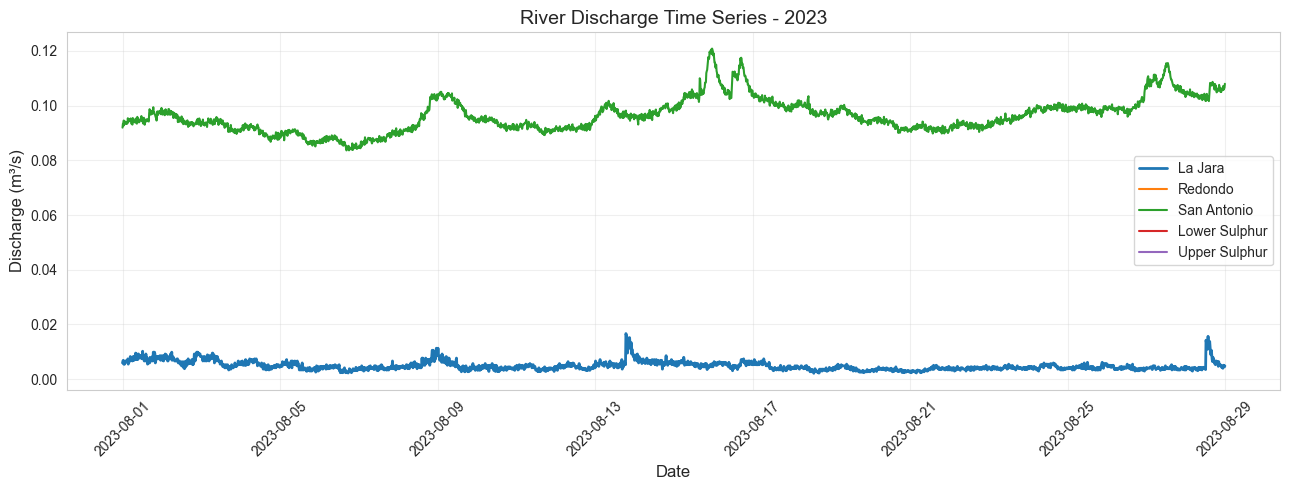

In [110]:
fig, ax = plt.subplots(figsize=(13, 5))
sns.set_style("whitegrid")

ax.plot(merged_2023.index, merged_2023['la_jara'], label='La Jara', linewidth=2)
ax.plot(merged_2023.index, merged_2023['redondo (m3/s)'], label='Redondo', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['san_antonio (m3/s)'], label='San Antonio', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['lower_sulphur (m3/s)'], label='Lower Sulphur', linewidth=1.5)
ax.plot(merged_2023.index, merged_2023['upper_sulphur (m3/s)'], label='Upper Sulphur', linewidth=1.5)

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Discharge (m³/s)', fontsize=12)
ax.set_title('River Discharge Time Series - 2023', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\huck4481\AppData\Local\Temp\ipykernel_11296\4291201678.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
C:\Users\huck4481\AppData\Local\Temp\ipykernel_11296\4291201678.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
C:\Users\huck4481\AppData\Local\Temp\ipykernel_11296\4291201678.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])


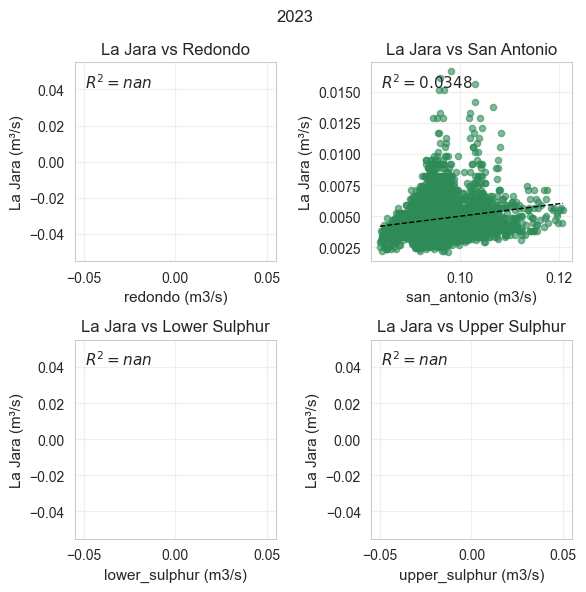

In [111]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
fig.suptitle('2023', fontsize=12)
sns.set_style("whitegrid")

# define the pairs: (x_column, subplot_position, title)
pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    # remove NaN values for the regression
    valid_data = merged_2023[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.6, s=20, color='seagreen')
    # Linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', transform=ax.transAxes, fontsize=11, verticalalignment='top')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## All years

In [72]:
# combine all years
merged_all = pd.concat([merged_2021, merged_2022])

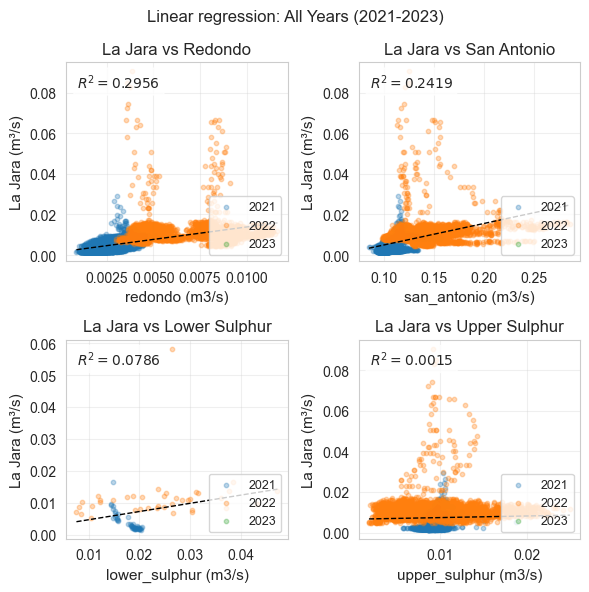

In [112]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}  # blue, orange, green

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    # scatter plot by year with different colors
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=10, color=color, label=year)
    
    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### Different curve types

In [74]:
from scipy.optimize import curve_fit

# define exponential function
def exponential(x, a, b):
    return a * np.exp(b * x)

def logarithmic(x, a, b):
    return a * np.log(x) + b

def power_law(x, a, b):
    return a * x**b

Exponential

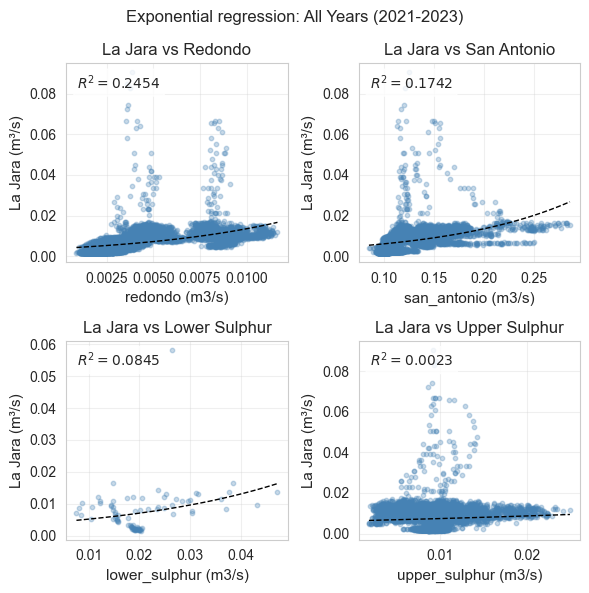

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # exponential regression
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = exponential(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * e^({popt[1]:.4f} * x)"
        equations.append(equation)
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 0.0392 * e^(34.4606 * x), R² = 0.0042
La Jara vs San Antonio: y = 0.0192 * e^(2.5120 * x), R² = 0.2485
La Jara vs Lower Sulphur: y = 0.0386 * e^(1.6576 * x), R² = 0.3079
La Jara vs Upper Sulphur: y = 0.0268 * e^(4.9820 * x), R² = 0.2373


Logarithmic

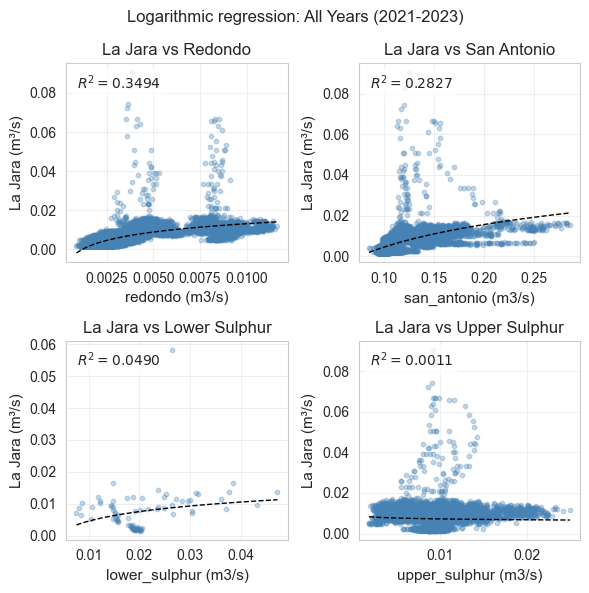

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Logarithmic regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # logarithmic regression
    try:
        popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = logarithmic(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = logarithmic(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(logarithmic, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * ln({popt[1]:.4f} * x)"
        equations.append(equation)
        y_pred = logarithmic(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 0.0062 * ln(0.0414 * x), R² = 0.3494
La Jara vs San Antonio: y = 0.0161 * ln(0.0414 * x), R² = 0.2827
La Jara vs Lower Sulphur: y = 0.0043 * ln(0.0245 * x), R² = 0.0490
La Jara vs Upper Sulphur: y = -0.0006 * ln(0.0044 * x), R² = 0.0011


Power Law

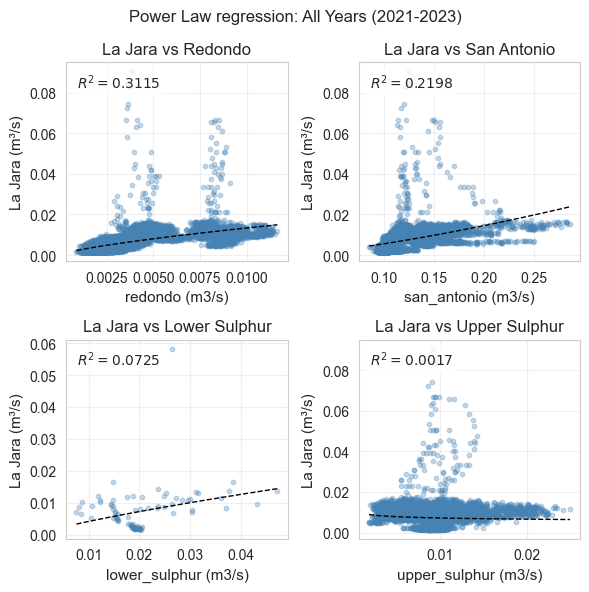

In [78]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Power Law regression: All Years (2021-2023)', fontsize=12)

pairs = [
    ('redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    ('san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    ('lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    ('upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot
    ax.scatter(x, y, alpha=0.3, s=10, color='steelblue')
    # power law regression
    try:
        popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = power_law(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        
        # plot regression line
        x_line = np.linspace(x.min(), x.max(), 100)
        y_line = power_law(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
    
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
# print the equations for each subplot
equations = []
for x_col, ax, title in pairs:
    valid_data = merged_all[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    try:
        popt, _ = curve_fit(power_law, x, y, p0=[0.01, 0.1], maxfev=5000)
        equation = f"y = {popt[0]:.4f} * x^{popt[1]:.4f}"
        equations.append(equation)
        y_pred = power_law(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        print(f"{title}: {equation}, R² = {r2:.4f}")
    except:
        equations.append("Failed to fit")
        print(f"{title}: Failed to fit")

La Jara vs Redondo: y = 0.3885 * x^0.7324, R² = 0.3115
La Jara vs San Antonio: y = 0.1346 * x^1.3845, R² = 0.2198
La Jara vs Lower Sulphur: y = 0.1661 * x^0.8004, R² = 0.0725
La Jara vs Upper Sulphur: y = 0.0041 * x^-0.1239, R² = 0.0017


# Only fitting lower range of data

In [80]:
# finding the max value of the low-flow period in 2022
redondo_low_flow_2022 = merged_all['redondo (m3/s)'][(merged_all.index >= '2022-09-10') & (merged_all.index <= '2023-03-10')]
san_antonio_low_flow_2022 = merged_all['san_antonio (m3/s)'][(merged_all.index >= '2022-09-01') & (merged_all.index <= '2023-03-10')]
lower_sulphur_low_flow_2022 = merged_all['lower_sulphur (m3/s)'][(merged_all.index >= '2022-09-01') & (merged_all.index <= '2023-03-10')]
upper_sulphur_low_flow_2022 = merged_all['upper_sulphur (m3/s)'][(merged_all.index >= '2022-09-01') & (merged_all.index <= '2023-03-10')]

print(f"Max Redondo low flow 2022: {redondo_low_flow_2022.max():.4f} m³/s")
print(f"Max San Antonio low flow 2022: {san_antonio_low_flow_2022.max():.4f} m³/s")
print(f"Max Lower Sulphur low flow 2022: {lower_sulphur_low_flow_2022.max():.4f} m³/s")
print(f"Max Upper Sulphur low flow 2022: {upper_sulphur_low_flow_2022.max():.4f} m³/s")

Max Redondo low flow 2022: 0.0049 m³/s
Max San Antonio low flow 2022: 0.1503 m³/s
Max Lower Sulphur low flow 2022: 0.0432 m³/s
Max Upper Sulphur low flow 2022: 0.0222 m³/s


In [81]:
merged_redondo = merged_all[['redondo (m3/s)', 'la_jara']].dropna()
merged_san_antonio = merged_all[['san_antonio (m3/s)', 'la_jara']].dropna()
merged_lower_sulphur = merged_all[['lower_sulphur (m3/s)', 'la_jara']].dropna()
merged_upper_sulphur = merged_all[['upper_sulphur (m3/s)', 'la_jara']].dropna()

# only keep rows where discharge is less than or equal to the max low flow 
merged_redondo = merged_redondo[merged_redondo['redondo (m3/s)'] <= redondo_low_flow_2022.max()]
merged_san_antonio = merged_san_antonio[merged_san_antonio['san_antonio (m3/s)'] <= san_antonio_low_flow_2022.max()]
merged_lower_sulphur = merged_lower_sulphur[merged_lower_sulphur['lower_sulphur (m3/s)'] <= lower_sulphur_low_flow_2022.max()]
merged_upper_sulphur = merged_upper_sulphur[merged_upper_sulphur['upper_sulphur (m3/s)'] <= upper_sulphur_low_flow_2022.max()]

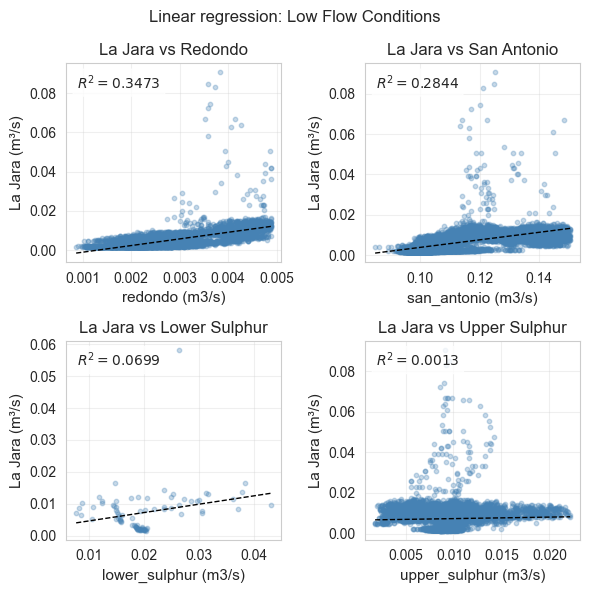

In [82]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Linear regression: Low Flow Conditions', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    # scatter plot
    ax.scatter(valid_data[x_col], valid_data['la_jara'], alpha=0.3, s=10, color='steelblue')
    
    # linear regression
    slope, intercept, r_value, p_value, std_err = linregress(valid_data[x_col], valid_data['la_jara'])
    r2 = r_value**2
    
    # plot regression line
    x_line = np.array([valid_data[x_col].min(), valid_data[x_col].max()])
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
    
    # Labels and title with R² value
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

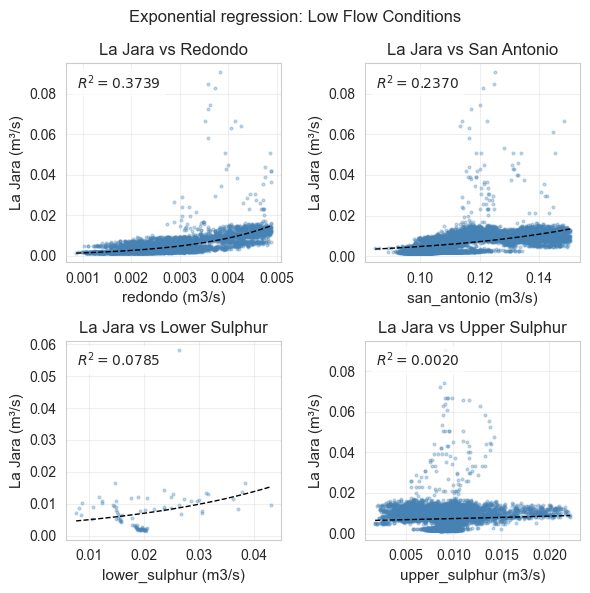

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: Low Flow Conditions', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]
for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    x = valid_data[x_col].values
    y = valid_data['la_jara'].values
    
    # scatter plot by year with different colors
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        ax.scatter(year_data[x_col], year_data['la_jara'], alpha=0.3, s=4, color='steelblue', label=year)
    
    # exponential regression
    try:
        popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
        
        # Calculate R²
        y_pred = exponential(x, *popt)
        residuals = y - y_pred
        ss_res = np.sum(residuals**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
    
        # plot regression line
        x_line = np.linspace(valid_data[x_col].min(), valid_data[x_col].max(), 100)
        y_line = exponential(x_line, *popt)
        ax.plot(x_line, y_line, color='black', linestyle='--', linewidth=1)
        # Labels and title with R² value
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.text(0.05, 0.95, f'$R^2 = {r2:.4f}$', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.grid(True, alpha=0.3)
    except:
        ax.set_xlabel(x_col, fontsize=11)
        ax.set_ylabel('La Jara (m³/s)', fontsize=11)
        ax.set_title(title + ' (fit failed)', fontsize=12)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


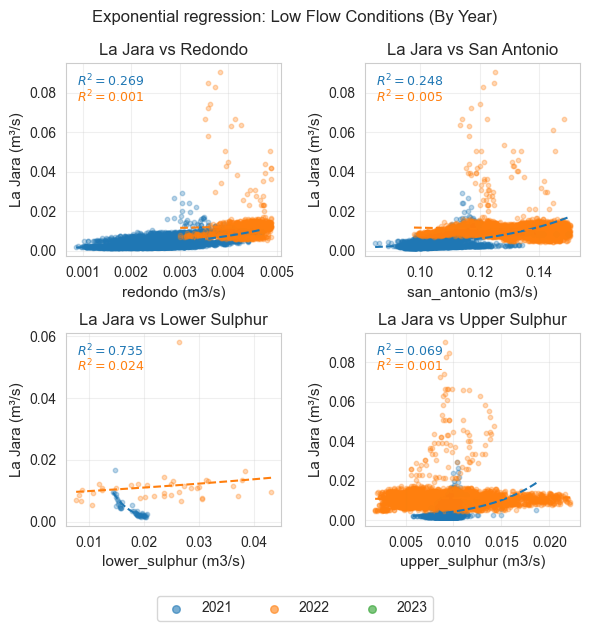

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.set_style("whitegrid")
fig.suptitle('Exponential regression: Low Flow Conditions (By Year)', fontsize=12)

pairs = [
    (merged_redondo, 'redondo (m3/s)', axes[0, 0], 'La Jara vs Redondo'),
    (merged_san_antonio, 'san_antonio (m3/s)', axes[0, 1], 'La Jara vs San Antonio'),
    (merged_lower_sulphur, 'lower_sulphur (m3/s)', axes[1, 0], 'La Jara vs Lower Sulphur'),
    (merged_upper_sulphur, 'upper_sulphur (m3/s)', axes[1, 1], 'La Jara vs Upper Sulphur')
]

colors = {'2021': '#1f77b4', '2022': '#ff7f0e', '2023': '#2ca02c'}  # blue, orange, green

for df, x_col, ax, title in pairs:
    valid_data = df[[x_col, 'la_jara']].dropna()
    y_position = 0.95
    
    # fit exponential regression for each year separately
    for year, color in colors.items():
        year_data = valid_data[valid_data.index.year == int(year)]
        
        if len(year_data) > 0:
            x = year_data[x_col].values
            y = year_data['la_jara'].values
            
            # scatter plot
            ax.scatter(x, y, alpha=0.3, s=10, color=color, label=year)
            
            # exponential regression for this year
            try:
                popt, _ = curve_fit(exponential, x, y, p0=[0.01, 0.1], maxfev=5000)
                
                # Calculate R²
                y_pred = exponential(x, *popt)
                residuals = y - y_pred
                ss_res = np.sum(residuals**2)
                ss_tot = np.sum((y - np.mean(y))**2)
                r2 = 1 - (ss_res / ss_tot)
                
                # plot regression line
                x_line = np.linspace(x.min(), x.max(), 100)
                y_line = exponential(x_line, *popt)
                ax.plot(x_line, y_line, color=color, linestyle='--', linewidth=1.5)
                
                # Add R² text with matching color
                ax.text(0.05, y_position, f'$R^2 = {r2:.3f}$', 
                       transform=ax.transAxes, fontsize=9, verticalalignment='top',
                       color=color, weight='bold')
                y_position -= 0.08
                
            except:
                pass
    
    # Labels and title
    ax.set_xlabel(x_col, fontsize=11)
    ax.set_ylabel('La Jara (m³/s)', fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.grid(True, alpha=0.3)

# Create a single legend at the bottom
handles = [plt.scatter([], [], color=colors[year], s=30, alpha=0.6) for year in ['2021', '2022', '2023']]
fig.legend(handles, ['2021', '2022', '2023'], loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.12)
plt.show()